# Healthcare Demand Forecasting

This notebook develops a forecasting model to predict future healthcare encounter demand using historical encounter trends.

Accurate demand forecasts can support workforce planning, resource allocation, and operational decision-making within healthcare organizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
patients = pd.read_csv("patients_clean.csv")
encounters = pd.read_csv("encounters_clean.csv")
conditions = pd.read_csv("conditions_clean.csv")
providers = pd.read_csv("providers_clean.csv")
organizations = pd.read_csv("organizations_clean.csv")

## Monthly Encounter Trend

The encounter dataset is aggregated at the monthly level to create a time series representing healthcare demand over time.

In [8]:
encounters['encounter_start'] = pd.to_datetime(
    encounters['encounter_start'],
    utc=True
)

In [9]:
monthly_encounters = (
    encounters
    .set_index('encounter_start')
    .resample('ME')
    .size()
)

In [10]:
print(monthly_encounters.head())
print(monthly_encounters.tail())
print(monthly_encounters.shape)

encounter_start
1912-09-30 00:00:00+00:00    1
1912-10-31 00:00:00+00:00    1
1912-11-30 00:00:00+00:00    0
1912-12-31 00:00:00+00:00    0
1913-01-31 00:00:00+00:00    0
Freq: ME, dtype: int64
encounter_start
2021-07-31 00:00:00+00:00    340
2021-08-31 00:00:00+00:00    339
2021-09-30 00:00:00+00:00    321
2021-10-31 00:00:00+00:00    319
2021-11-30 00:00:00+00:00    190
Freq: ME, dtype: int64
(1311,)


In [11]:
monthly_encounters = monthly_encounters[
    monthly_encounters.index >= '2000-01-01'
]

## Historical Healthcare Demand

This visualization shows monthly healthcare encounter volume over time and helps identify trends, seasonality, and demand fluctuations.

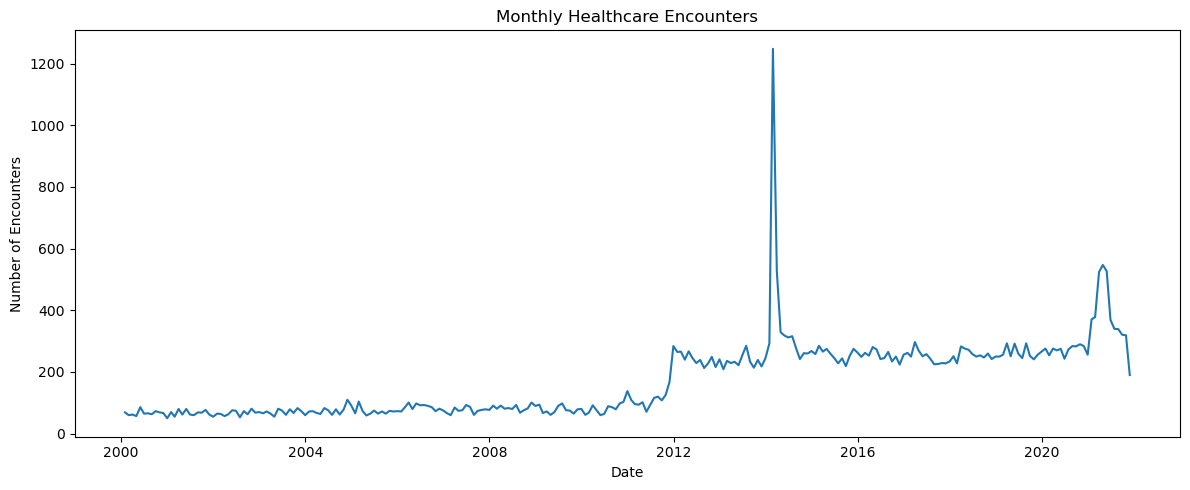

In [12]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_encounters.index,
    monthly_encounters.values
)

plt.title('Monthly Healthcare Encounters')
plt.xlabel('Date')
plt.ylabel('Number of Encounters')

plt.tight_layout()
plt.show()

## Train-Test Split

The last 12 months are reserved for testing, while the remaining observations are used to train the forecasting model.

In [13]:
train = monthly_encounters[:-12]
test = monthly_encounters[-12:]

print("Train:", train.shape)
print("Test:", test.shape)

Train: (251,)
Test: (12,)


## Forecast Model Development

Holt-Winters Exponential Smoothing is used because it can capture trend and seasonal patterns commonly found in healthcare demand data.

In [14]:
model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

fitted_model = model.fit()

In [15]:
forecast = fitted_model.forecast(
    len(test)
)

## Model Performance Evaluation

Forecast accuracy is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [17]:
mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 102.47
RMSE: 131.21


## Actual vs Forecast Comparison

This visualization compares actual healthcare demand with forecasted demand for the test period.

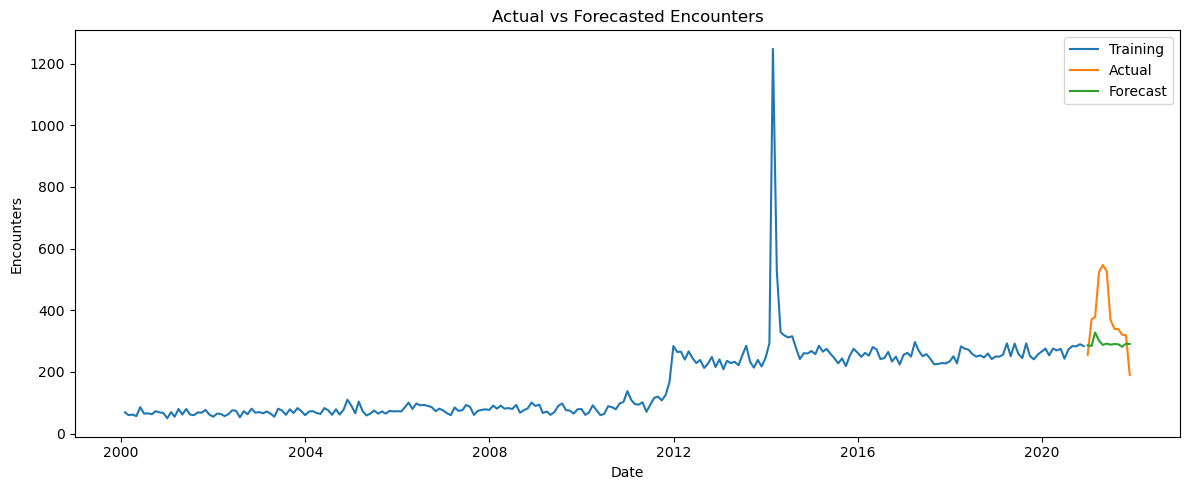

In [18]:
plt.figure(figsize=(12,5))

plt.plot(
    train.index,
    train,
    label='Training'
)

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    forecast.index,
    forecast,
    label='Forecast'
)

plt.title('Actual vs Forecasted Encounters')
plt.xlabel('Date')
plt.ylabel('Encounters')

plt.legend()

plt.tight_layout()
plt.show()

In [19]:
final_model = ExponentialSmoothing(
    monthly_encounters,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

final_model = final_model.fit()

## Future Healthcare Demand Forecast

The final model is trained on the complete historical dataset and used to forecast healthcare demand for the next 12 months.

In [20]:
future_forecast = final_model.forecast(12)

future_forecast

2021-12-31 00:00:00+00:00    295.880067
2022-01-31 00:00:00+00:00    296.511482
2022-02-28 00:00:00+00:00    341.462101
2022-03-31 00:00:00+00:00    319.475241
2022-04-30 00:00:00+00:00    306.826969
2022-05-31 00:00:00+00:00    309.022470
2022-06-30 00:00:00+00:00    299.520818
2022-07-31 00:00:00+00:00    302.533158
2022-08-31 00:00:00+00:00    301.369963
2022-09-30 00:00:00+00:00    292.775042
2022-10-31 00:00:00+00:00    302.141288
2022-11-30 00:00:00+00:00    296.217505
Freq: ME, dtype: float64

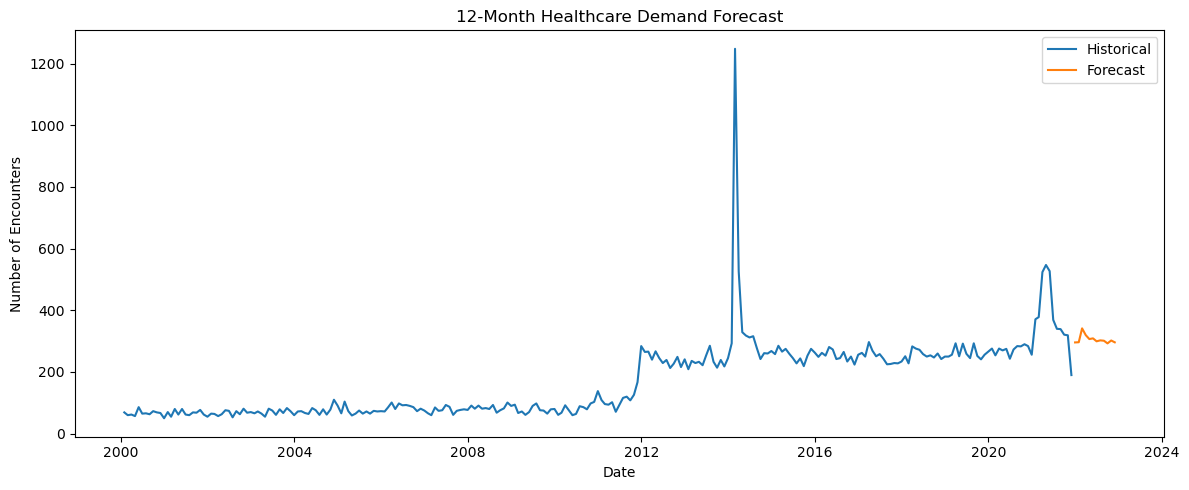

In [21]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_encounters.index,
    monthly_encounters,
    label='Historical'
)

plt.plot(
    future_forecast.index,
    future_forecast,
    label='Forecast'
)

plt.title('12-Month Healthcare Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Encounters')

plt.legend()

plt.tight_layout()
plt.show()

In [22]:
forecast_df = pd.DataFrame({
    'forecasted_encounters': future_forecast
})

forecast_df

,forecasted_encounters
2021-12-31 00:00:00+00:00,295.880067
2022-01-31 00:00:00+00:00,296.511482
2022-02-28 00:00:00+00:00,341.462101
2022-03-31 00:00:00+00:00,319.475241
2022-04-30 00:00:00+00:00,306.826969
2022-05-31 00:00:00+00:00,309.022470
2022-06-30 00:00:00+00:00,299.520818
2022-07-31 00:00:00+00:00,302.533158
2022-08-31 00:00:00+00:00,301.369963
2022-09-30 00:00:00+00:00,292.775042


# Forecasting Summary

A Holt-Winters Exponential Smoothing model was developed to forecast future healthcare encounter demand using historical monthly encounter data.

The model was trained on historical encounter volumes and evaluated using a holdout test set consisting of the most recent 12 months.

## Model Performance

- Mean Absolute Error (MAE): 102.47 encounters
- Root Mean Squared Error (RMSE): 131.21 encounters

The model successfully captured the overall level and trend of healthcare demand, although prediction accuracy was affected by several significant utilization spikes present within the historical data.

## Future Demand Forecast

The forecast predicts monthly healthcare encounter volumes to remain relatively stable over the next 12 months, ranging between approximately 290 and 340 encounters per month.

This suggests that healthcare demand is expected to remain consistent in the near future without major growth or decline.

## Business Recommendations

Based on the exploratory and forecasting analyses, the following recommendations are proposed:

1. Expand preventive care and chronic disease management programs for older patient populations, which account for the highest overall healthcare spending.

2. Monitor high-cost patients and develop targeted care management initiatives to reduce unnecessary healthcare expenditures.

3. Continue investing in ambulatory and wellness services, as these encounter types represent the largest share of healthcare activity.

4. Prioritize staffing and resource allocation within high-utilization healthcare organizations to support growing patient demand.

5. Strengthen primary care capacity, as General Practice providers represent the largest segment of the healthcare workforce.

6. Incorporate demand forecasting into operational planning processes to better anticipate future healthcare utilization and staffing requirements.